In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2001-01-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

returns["change"] = np.log(returns["Close"]).diff()
returns = returns.dropna()
returns = returns[["Close", "change"]]
returns


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,change
Date,,
2001-01-03,1347.560059,0.048884
2001-01-04,1333.339966,-0.010609
2001-01-05,1298.349976,-0.026593
2001-01-08,1295.859985,-0.001920
2001-01-09,1300.800049,0.003805
...,...,...
2025-04-30,5569.060059,0.001479
2025-05-01,5604.140137,0.006279
2025-05-02,5686.669922,0.014619


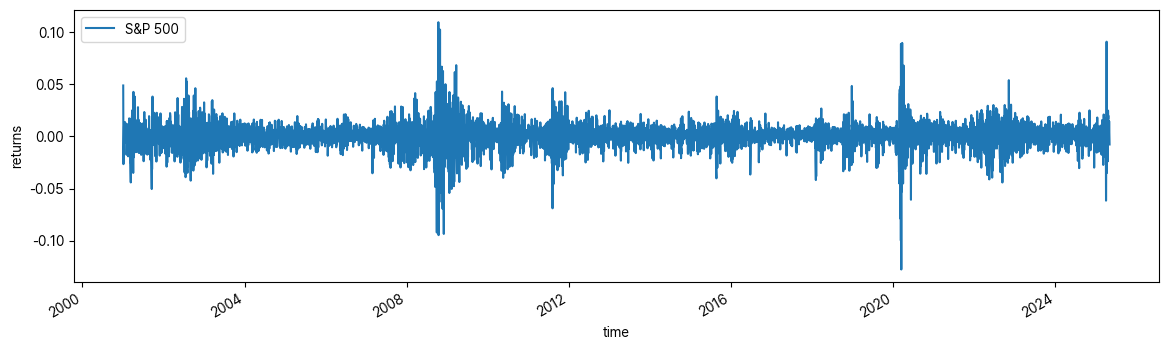

In [2]:
fig, ax = plt.subplots(figsize=(14, 4))
returns.plot(y="change", label="S&P 500", ax=ax)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [3]:
def make_stochastic_volatility_model(data):
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        volatility = pm.GaussianRandomWalk("volatility", sigma=step_size, dims="time")
        nu = pm.Exponential("nu", 0.1)
        returns = pm.StudentT(
            "returns", nu=nu, lam=np.exp(-2 * volatility), observed=data["change"], dims="time"
        )
    return model


stochastic_vol_model = make_stochastic_volatility_model(returns)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


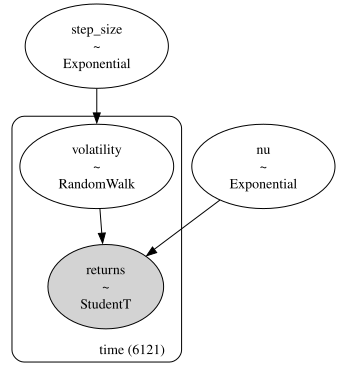

In [4]:
pm.model_to_graphviz(stochastic_vol_model)

In [5]:
rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [6]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [nu, returns, step_size, volatility]


In [7]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 6121, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2001-01-03 2001-01-04 ... 2025-05-06
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 7.807e+44 8.437e+39 ... 1.036e-51
Attributes:
    created_at:                 2025-05-07T19:13:29.615643
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [8]:
prior_predictive["returns"].shape

(6121, 500)

/tmp/ipykernel_47461/930709764.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


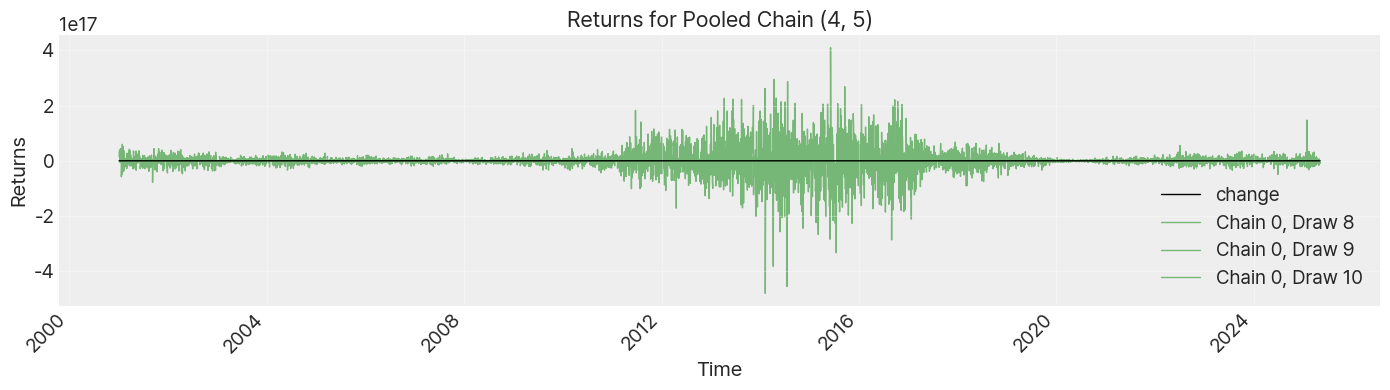

In [9]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(8, 11, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
with stochastic_vol_model:
    idata.extend(pm.sample(6000, tune=2000, random_seed=rng, target_accept=0.95))

posterior = idata.posterior.stack(pooled_chain=("chain", "draw"))
posterior["exp_volatility"] = np.exp(posterior["volatility"])

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [step_size, volatility, nu]


Sampling 4 chains for 2_000 tune and 6_000 draw iterations (8_000 + 24_000 draws total) took 5924 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [11]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
step_size,0.081,0.006,0.07,0.091,0.0,0.0,283.0,580.0,1.02


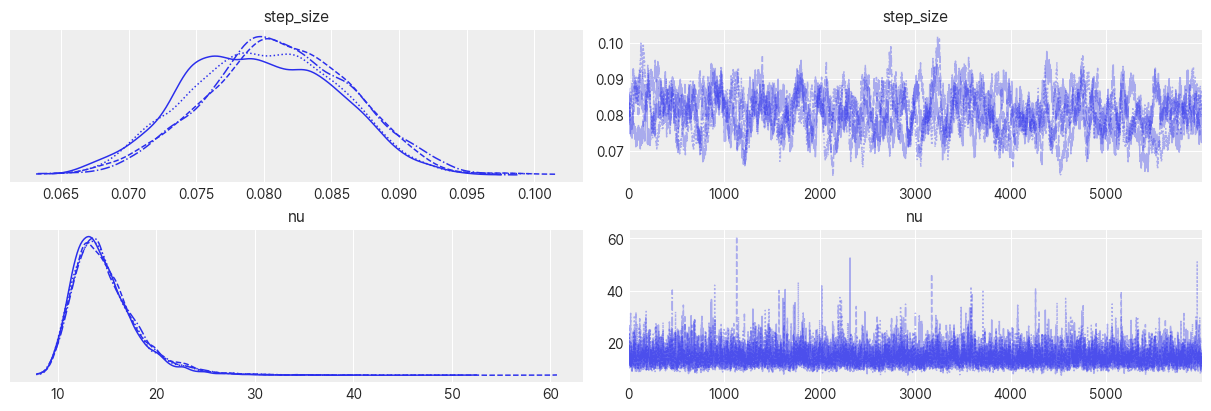

In [12]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [13]:
with stochastic_vol_model:
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=rng))

posterior_predictive = idata.posterior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [returns]


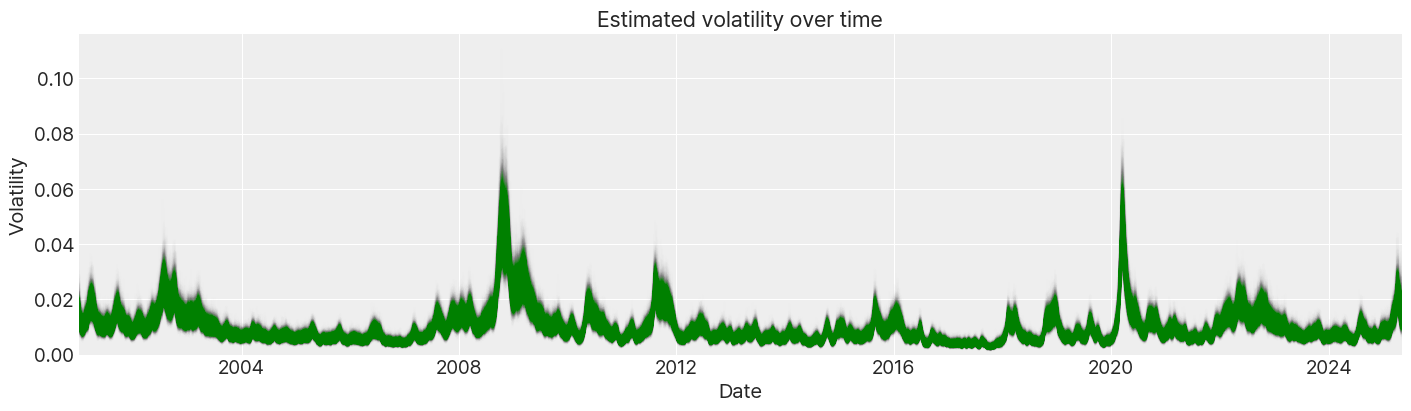

: 

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["exp_volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["change"].plot(ax=axes[0], color="black")

y_vals = posterior["exp_volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.005)

y_vals = posterior_predictive["returns"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.005,
    zorder=-10)
axes[0].set_title("True log returns (black) and posterior predictive log returns (green)")
axes[1].set_title("Posterior volatility");